In [1]:
import os
import glob
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
from collections import defaultdict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    f1_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)


In [2]:
def safe_cw_auc(targets, scores, mode = 'ovo', count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)
    unique_targets = unique_targets[counts > count_lim]
    cw_auc = np.full(scores.shape[-1], np.nan)
    if len(unique_targets) == 1:
        return cw_auc
    for k in unique_targets:
        if mode == 'ovo':
            cw_auc[k] = 0
            for l in unique_targets:
                if l == k: continue
                tmp_mask = np.logical_or(targets == k, targets == l)
                tmp_targets = targets[tmp_mask]
                tmp_scores = scores[tmp_mask, k]
                cw_auc_kvl = roc_auc_score(tmp_targets == k,tmp_scores)
                cw_auc[k] += cw_auc_kvl/(len(unique_targets -1))
        elif mode == 'ovr':
            cw_auc[k] = roc_auc_score(targets == k, scores[:, k])
        else:
            raise "Mode must be ovo or ovr"
    return cw_auc

def safe_cw_pr_re_f1(targets, preds, num_classes, count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)

    # Target count filter
    count_filt = np.full(num_classes, np.nan)
    count_filt[unique_targets[counts > count_lim]] = 1 

    # Calculate scores (results will only include present targets)
    cw_prec = precision_score(targets, preds, average=None, zero_division=np.nan)
    cw_rec = recall_score(targets, preds, average=None, zero_division=np.nan)
    cw_f1 = f1_score(targets, preds, average=None, zero_division=np.nan)

    # Initialize NaN arrays to fill to make sure all possible targets are representet
    cw_prec_array = np.full(num_classes, np.nan)
    cw_rec_array = np.full(num_classes, np.nan)
    cw_f1_array = np.full(num_classes, np.nan)

    # Fill in NaN arrays
    for i, k in enumerate(unique_targets):
        cw_prec_array[k] = cw_prec[i] * count_filt[i]
        cw_rec_array[k] = cw_rec[i] * count_filt[i]
        cw_f1_array[k] = cw_f1[i] * count_filt[i]

    return cw_prec_array, cw_rec_array, cw_f1_array

def calc_sleep_summary_metrics(stages, label_map):
    metrics = {}
    # Calculate TST
    sleep = stages != label_map['wake']
    tst = (sleep).sum()
    metrics['tst'] = float(tst)
    
    try:
        # Calculate SOL (first consecutive 3-epoch sleep window)
        # [[sleep, False, False],
        # [False, sleep, False],
        # [False, False, sleep]]
        sleep_shifted = np.stack([
            np.append(sleep, [False, False]),
            np.insert(np.append(sleep, [False]), 0, [False]),
            np.insert(sleep, 0, [False, False]),
        ])
        sol = np.argwhere(sleep_shifted.all(axis=0)).min()
        metrics['sol'] = float(sol)

        # Calculate WASO, how to handle missing?
        # Trim back from the last index if it is wake
        # Find last index of sleep 
        last_sleep = np.argwhere(stages != label_map['wake']).max() + 1
        waso = (stages[sol: last_sleep] == label_map['wake']).sum()
        metrics['waso'] = float(waso)
    except:
        metrics['sol'] = np.nan
        metrics['waso'] = np.nan
    # Calculate SE
    # se = (stages[sol: last_sleep] != label_map['wake']).sum() / (last_sleep - sol)
    se = (stages != label_map['wake']).sum() / len(stages)
    metrics['se'] = float(se)

    # Calculate REM
    rem = (stages == ss_label_map['rem']).sum()
    metrics['rem'] = float(rem)
    
    # Calculate Deep
    deep = (stages == ss_label_map['deep']).sum()
    metrics['deep'] = float(deep)

    # Calculate Light
    light = (stages == ss_label_map['light']).sum()
    metrics['light'] = float(light)

    # Calculate NREM
    nrem = light + deep
    metrics['nrem'] = float(nrem)

    return metrics


In [3]:
ss_labels_name = 'light_deep_rem'
ss_label_map = {
    'deep': 0,
    'light': 1,
    'rem': 2,
    'wake': 3,
    'missing': -9,
}
# ss_label_map_inv = {val: key for key, val in ss_label_map.items()}
ss_label_map_inv = {val: key for key, val in ss_label_map.items() if val != -9}
ss_label_order = ['wake', 'light', 'deep', 'rem']
ss_label_name = ['Wake', 'Light', 'Deep', 'REM']

ss_colormap = {
    'wake': 'tab:red',
    'Wake': 'tab:red',
    'light': 'tab:orange',
    'Light': 'tab:orange',
    'deep': 'tab:blue',
    'Deep': 'tab:blue',
    'rem': 'tab:green',
    'REM': 'tab:green',
}
ss_case_map = {
    'wake':'Wake',
    'light': 'Light',
    'deep': 'Deep',
    'rem': 'REM',
}

# apnea_labels_name = 'apnea'
# apnea_label_map = {
#     'none': 0,
#     'ha': 1,
#     'oa': 2,
#     'ca': 2,
# }
# apnea_label_order = ['none', 'ha', 'oa']
# apnea_label_names = ['None', 'HA', 'OA/CA']

In [11]:
## Subject-wise performance metrics
cw_precs = defaultdict(list)
cw_recalls = defaultdict(list)
cw_f1s = defaultdict(list)

cw_aucs = defaultdict(list)
roc_curves = defaultdict(list)
soft_preds_all = []
targets_all = []

macro_results = defaultdict(list)
summary_diffs = defaultdict(list)
summary_means = defaultdict(list)
exp_i = []
subject_i = []
dataset_i = []

exp_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_external/'
experiments = [('Full Internal', exp_path)]
for exp_name, experiment_dir in experiments:
    for dataset in os.scandir(experiment_dir):
        for sub_dir in os.scandir(dataset):
            subject_i.append(os.path.basename(sub_dir))
            dataset_i.append(os.path.basename(dataset))
            exp_i.append(exp_name)

            missing_idx = ss_label_map['missing']

            scores = np.load(os.path.join(sub_dir.path + '/soft_preds.npy'))
            targets = np.load(os.path.join(sub_dir.path + '/targets.npy'))

            scores = scores[targets != missing_idx]
            targets = targets[targets != missing_idx]
            
            # Quick fix for extra NaNs in scores
            if np.any(np.isnan(scores)):
                print(f'{np.sum(np.isnan(scores))}/{len(scores)} NaN found in {sub_dir}')
                targets = targets[~np.any(np.isnan(scores),axis=1)]
                scores = scores[~np.any(np.isnan(scores),axis=1)]

            soft_preds_all.append(scores)
            targets_all.append(targets)
            
            # Get hard predictions
            preds = scores.argmax(axis=-1)

            unique_targets, counts = np.unique(targets, return_counts=True)
            unique_preds, pred_counts = np.unique(preds, return_counts=True)

            ## Subject-wise class-wise scores
            # Precision, Recall, and F1
            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=scores.shape[-1], count_lim=3)
            
            # Manually compute binary AUC for each label present (NaN for non-valid)
            cw_auc = safe_cw_auc(targets, scores, mode='ovr', count_lim=3)

            for k in range(scores.shape[-1]):
                cw_aucs[ss_label_map_inv[k]].append(float(cw_auc[k]))
                cw_precs[ss_label_map_inv[k]].append(float(cw_pr[k]))
                cw_recalls[ss_label_map_inv[k]].append(float(cw_re[k]))
                cw_f1s[ss_label_map_inv[k]].append(float(cw_f1[k]))

            # Class-wise ROC curves
            for k in unique_targets:
                roc = roc_curve(targets, scores[:,k], pos_label=k)
                roc_curves[ss_label_map_inv[k]].append(roc)
            
            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            kappa = cohen_kappa_score(targets, preds)
            macro_results['Precision'].append(mac_prec)
            macro_results['Recall'].append(mac_rec)
            macro_results['F1'].append(mac_f1)
            macro_results['Kappa'].append(kappa)
            macro_results['AUC'].append(np.nanmean(cw_auc))

            pred_metrics = calc_sleep_summary_metrics(preds, ss_label_map)
            target_metrics = calc_sleep_summary_metrics(targets, ss_label_map)
            summary_diff = {
                f'{key}': pred_metrics[key] - target_metrics[key]
                for key
                in pred_metrics.keys()
            }
            summary_mean = {
                f'{key}': (pred_metrics[key] + target_metrics[key])/2 
                for key 
                in pred_metrics.keys()
            }
            for key in summary_diff.keys():
                summary_diffs[key].append(summary_diff[key])
                summary_means[key].append(summary_mean[key])

macro_results = pd.DataFrame(data=macro_results)
cw_aucs = pd.DataFrame(data=cw_aucs)
cw_precs = pd.DataFrame(data=cw_precs)
cw_recalls = pd.DataFrame(data=cw_recalls)
cw_f1s = pd.DataFrame(data=cw_f1s)
summary_means = pd.DataFrame(data=summary_means)
summary_diffs = pd.DataFrame(data=summary_diffs)
for col in summary_means.columns:
    if col == 'se':
        factor = 100 # fraction to %
    else:
        factor = 0.5 # 30s epoch to minutes
    summary_diffs[col] = summary_diffs[col] * factor
    summary_means[col] = summary_means[col] * factor

soft_preds_all = np.concatenate(soft_preds_all)
targets_all = np.concatenate(targets_all)
preds_all = soft_preds_all.argmax(axis=-1)

8/959 NaN found in <DirEntry '4314139'>
4/738 NaN found in <DirEntry '1066528'>


In [9]:
def bland_altman(mean, diff, ax, annot_pos='right'):
    md = np.mean(diff) # Mean of the difference
    sd = np.std(diff) # Standard deviation of the difference

    # ax.grid(axis='y', zorder=0)
    ax.axhline(md, color='gray', linestyle='--',zorder=1)
    ax.axhline(0, color='gray', alpha=0.7, linestyle='-', zorder=0)

    loa_upper = md + 1.96*sd
    loa_lower = md - 1.96*sd
    ax.axhline(loa_upper, color='r', linestyle='--',)
    ax.axhline(loa_lower, color='r', linestyle='--')

    # ax.set_ylim(min(diff.min()*1.3, loa_lower*1.3), max(diff.max()*1.3, loa_upper*1.3))
    outlier_threshold = 3.0*sd
    upper_lim = md + outlier_threshold
    lower_lim = md - outlier_threshold
    ax.set_ylim(lower_lim, upper_lim)

    # Plot outliers
    out_up = mean[diff > upper_lim]
    if len(out_up) > 0:
        ax.scatter(out_up, np.repeat(upper_lim-outlier_threshold*0.03, len(out_up)), marker='^',color='k', s=3)
    out_down = mean[diff < lower_lim]
    if len(out_down) > 0:
        ax.scatter(out_down, np.repeat(lower_lim+outlier_threshold*0.03, len(out_down)), marker='v', color='k', s=3)

    ax.set_xlim(mean.min()-mean.max()*0.2, mean.max()*1.2)

    if annot_pos == 'left':
        pos = (0.2, -0.1)
        x = mean.min()*0.1
    elif annot_pos == 'right':
        pos = (-0.2, -0.1)
        x = mean.max()*1.1

    ax.annotate(
        f'Mean\n{round(md,1)}',
        xy=(x, md), xycoords='data',
        xytext=pos, textcoords='offset fontsize',
        fontsize='medium', verticalalignment='center', horizontalalignment=annot_pos,# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.annotate(
        f'+1.96 SD\n{round(loa_upper,1)}',
        xy=(x, loa_upper), xycoords='data',
        xytext=pos, textcoords='offset fontsize',
        fontsize='medium', verticalalignment='center', horizontalalignment=annot_pos,# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.annotate(
        f'-1.96 SD\n{round(loa_lower,1)}',
        xy=(x, loa_lower), xycoords='data',
        xytext=pos, textcoords='offset fontsize',
        fontsize='medium', verticalalignment='center', horizontalalignment=annot_pos,# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    return ax

In [13]:
dataset_i

['amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'amazfit',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel',
 'sleepaccel']

/tmp/ipykernel_11720/3000192266.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  cax = sns.boxplot(


UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

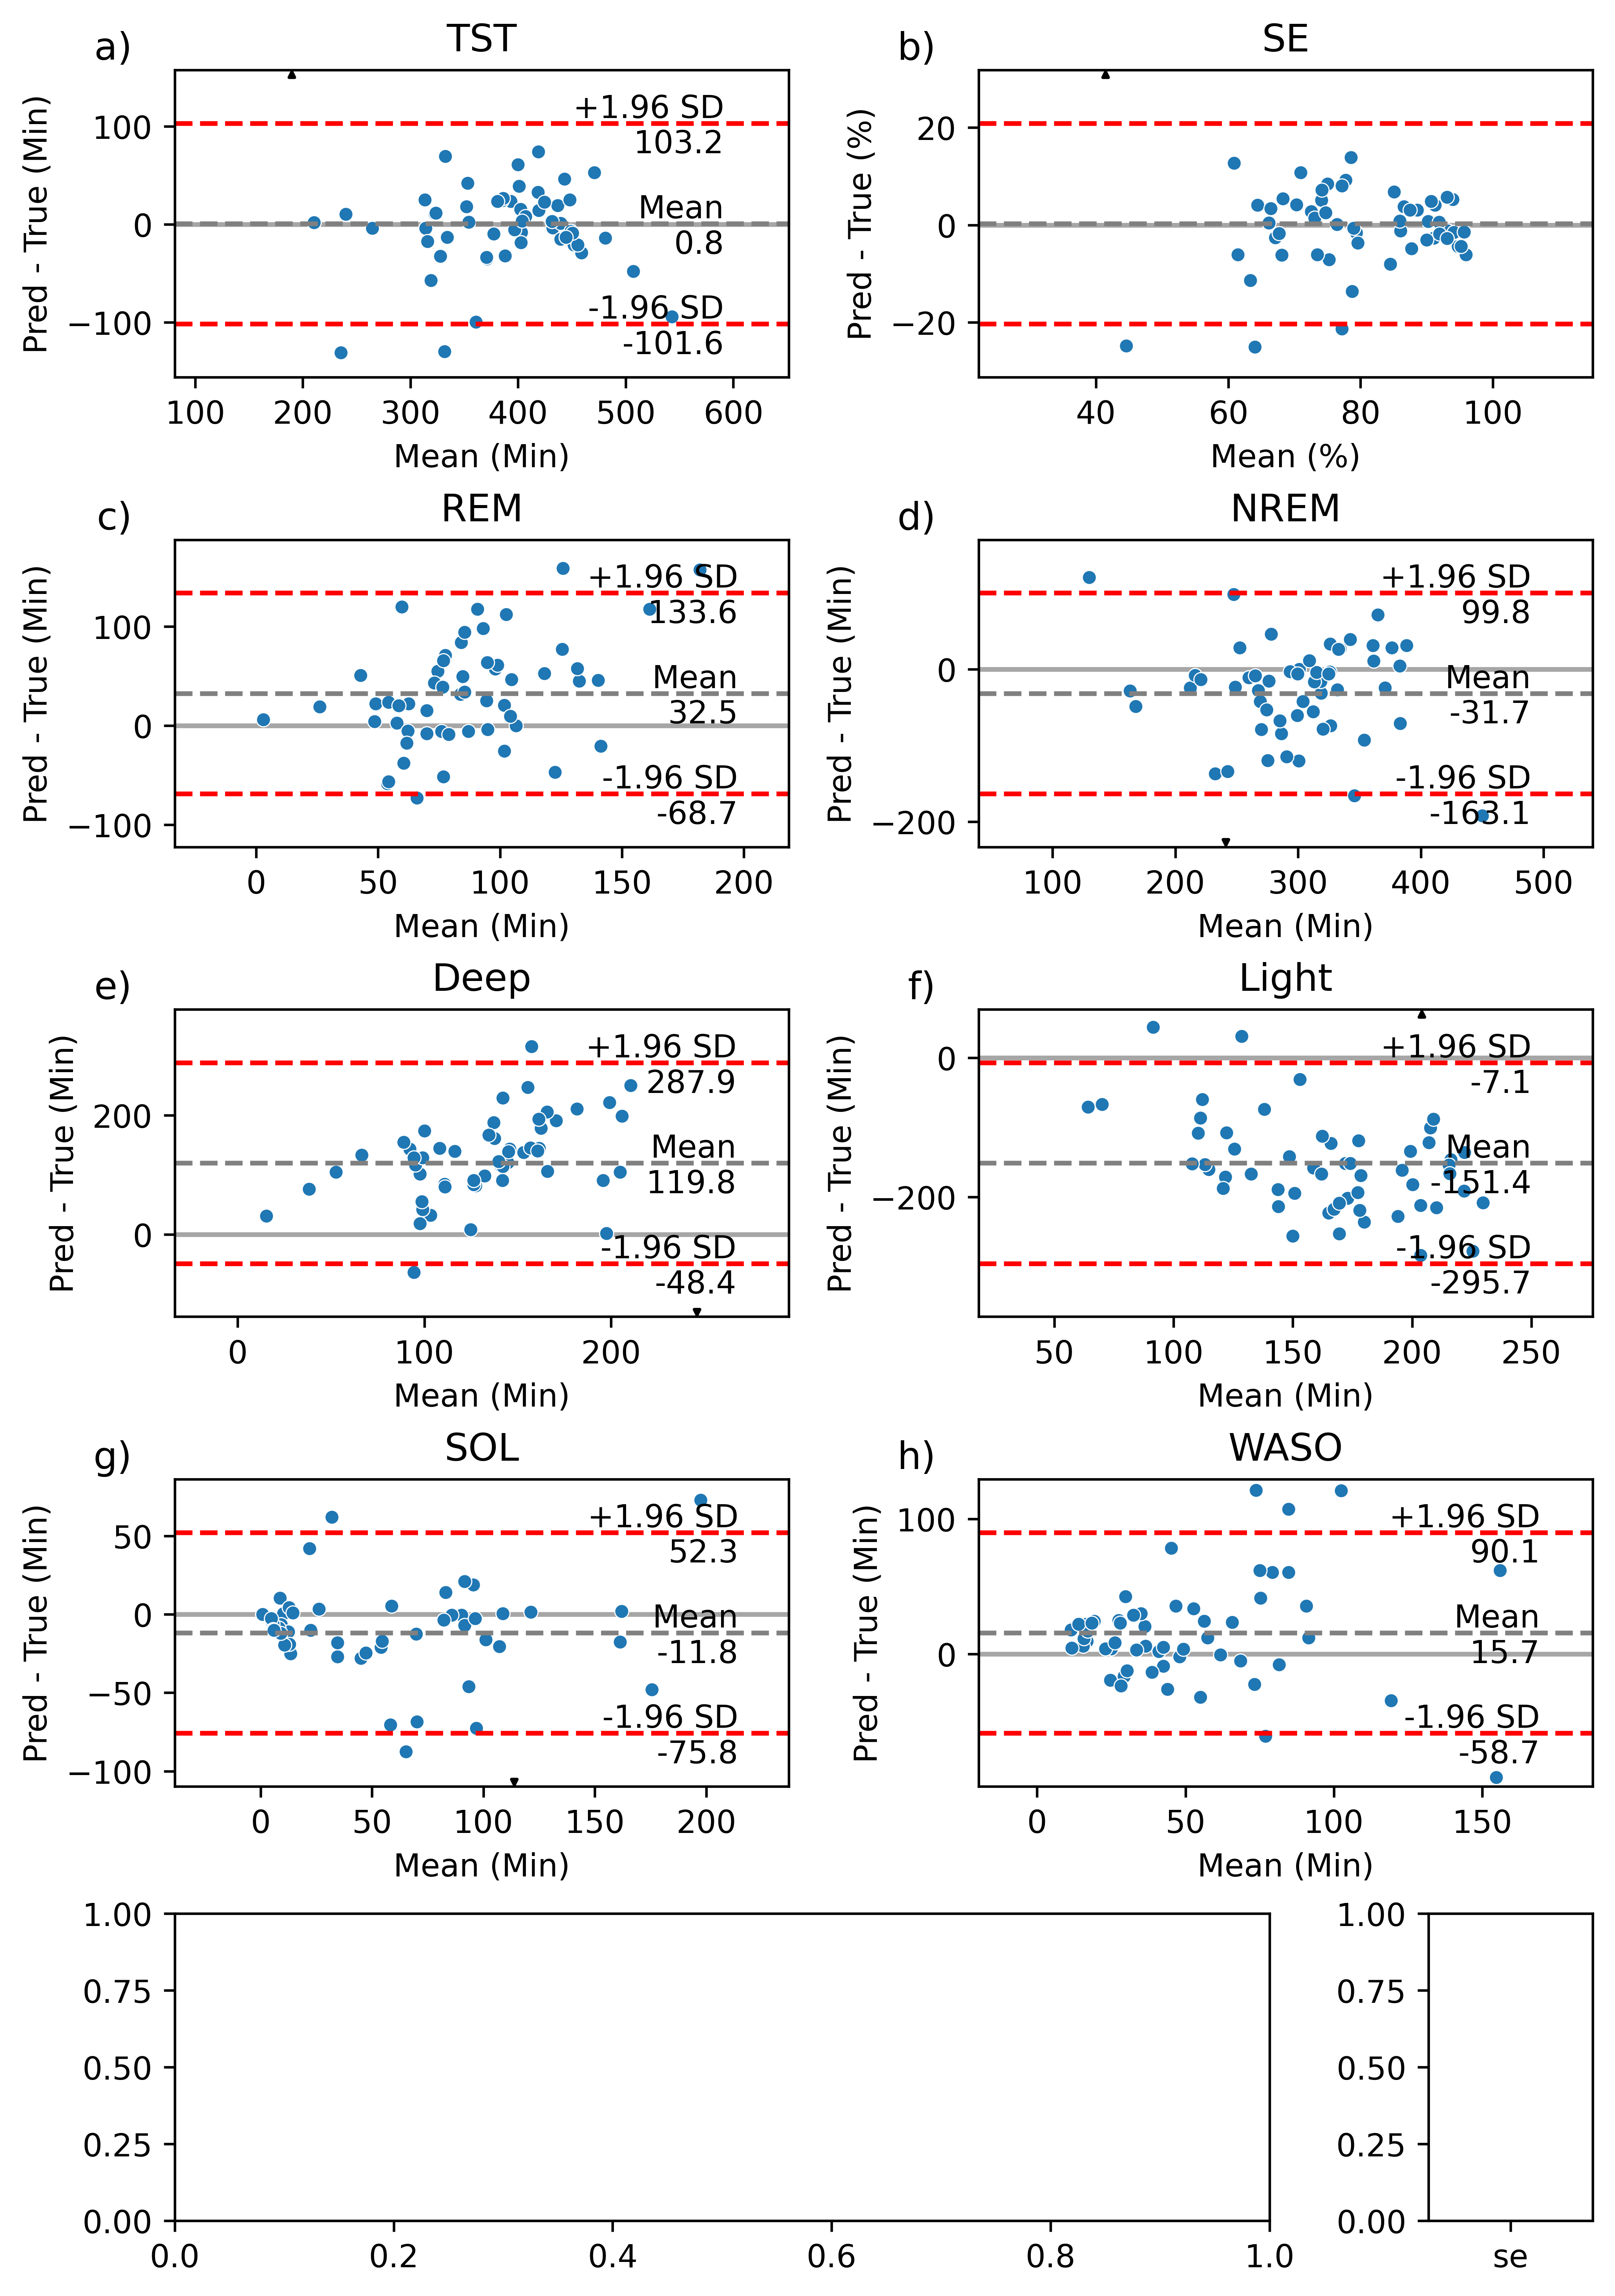

In [12]:
summary_diffs['dataset'] = dataset_i
summary_diffs['dataset'] = summary_diffs['dataset'].map({
    'newcastle_left': 'Newcastle L',
    'newcastle_right': 'Newcastle R',
    'stages': 'STAGES',
    'dreamt': 'DREAMT',
    'tbi': 'TBI',
})

layout = [
    ['TST', 'SE'],
    ['REM', 'NREM'],
    ['Deep','Light'],
    ['SOL', 'WASO'],
    ['Errors','Errors']
]
fig, axes = plt.subplot_mosaic(layout,figsize=(7,10), dpi=600, layout = 'constrained')
for i, (var, ax) in enumerate(axes.items()):

    if var == 'Errors':
        # Plot Summary metric errors
        # ax.set_title('Summary Metric Errors')
        # .drop(columns=['sol','se','waso'])
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="15%", pad=0.7)
        cax = sns.boxplot(
            summary_diffs[['se', 'dataset']].melt(id_vars=['dataset']), 
            x='variable', y='value', hue='dataset', 
            saturation=0.75, ax=cax, showfliers=False, palette='Dark2', legend=False,
            hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
        )
        cax.set_ylabel('Error (%)')
        cax.set_xlabel('')

        melt_summary = summary_diffs.drop(columns=['se']).melt(id_vars=['dataset'])
        melt_summary['variable'] = melt_summary['variable'].str.upper().replace({
            'LIGHT': 'Light',
            'DEEP': 'Deep',
        })
        ax = sns.boxplot(
            melt_summary, x='variable', y='value', hue='dataset', 
            saturation=0.75, ax=ax, showfliers=False, palette='Dark2',
            hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
        )
        ax.set_title('Error by Dataset')
        ax.set_ylabel('Error (Min)')
        ax.grid()
        ax.xaxis.set_label_position('top')
        ax.set_xlabel(' \n')
        ax.legend(
            title='', handletextpad = 0.3, columnspacing=0.6, 
            ncols=5, bbox_to_anchor=(-0.05,1.,1.15,1),mode='expand', loc='lower left',
        )

    else:
        #Convert from epochs to minutes or fraction to %
        diff = summary_diffs[var.lower()]
        mean = summary_means[var.lower()]
        ax = sns.scatterplot(
            x=mean, y=diff,s=20, ax=ax, #hue=summary_diffs['dataset'], 
            # legend=(i==0), palette='Dark2',
            # hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
        )
        bland_altman(mean, diff, ax, annot_pos='left' if var == 'SE' else 'right')
        ax.set_title(f'{var}')
        ax.set_xlabel('')
        if var == 'SE':
            ax.set_ylabel('Pred - True (%)')
            ax.set_xlabel('Mean (%)')
        else:
            ax.set_ylabel('Pred - True (Min)')
            ax.set_xlabel('Mean (Min)')
    # Add alphabetic ordering
    ax.annotate(
        f'{chr(97+i)})',
        xy=(-0.1, 1.07), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
fig.suptitle('Bland-Altmann plots for LSTM-C classifier')
